In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('internal_data_descriptor.csv')
df

C:\Users\krish\AppData\Local\Temp\ipykernel_80264\2494105310.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('internal_data_descriptor.csv')


,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,bioactivity_class
0,CHEMBL3929944,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
1,CHEMBL3397330,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
2,CHEMBL3605458,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
3,CHEMBL3605454,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
4,CHEMBL3605443,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11846,C96398094,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11847,C96927198,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11848,C65265984,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11849,C20744856,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive


In [5]:
df['bioactivity_class'].value_counts()

bioactivity_class
inactive        9589
active          1978
intermediate     284
Name: count, dtype: int64

In [7]:
df_2class = df[df.bioactivity_class != 'intermediate'] #dropping the value the intermediate class
df_2class

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,bioactivity_class
0,CHEMBL3929944,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
1,CHEMBL3397330,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
2,CHEMBL3605458,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
3,CHEMBL3605454,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
4,CHEMBL3605443,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11846,C96398094,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11847,C96927198,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11848,C65265984,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
11849,C20744856,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive


In [9]:
w = df_2class.drop('bioactivity_class', axis=1)
y = df_2class.bioactivity_class
x = w.drop('Name', axis=1)

In [11]:
y.replace(('active', 'inactive',),(1,0), inplace=True)
y

C:\Users\krish\AppData\Local\Temp\ipykernel_80264\601137051.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace(('active', 'inactive',),(1,0), inplace=True)
C:\Users\krish\AppData\Local\Temp\ipykernel_80264\601137051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.replace(('active', 'inactive',),(1,0), inplace=True)


0        1
1        0
2        1
3        1
4        1
        ..
11846    0
11847    0
11848    0
11849    0
11850    0
Name: bioactivity_class, Length: 11567, dtype: int64

In [13]:
from sklearn.feature_selection import VarianceThreshold

def remove_low_variance(input_data, threshold=0.1):
    selection = VarianceThreshold(threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices=True)]]

x = remove_low_variance(x, threshold=0.1)
x

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP37,PubchemFP43,PubchemFP143,...,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
0,0,0,0,0,0,0,0,1,0,1,...,1,0,0,1,0,0,1,0,0,0
1,1,0,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,0,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,1,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11846,0,0,1,0,0,0,0,0,0,1,...,1,0,0,0,0,1,0,0,1,0
11847,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
11848,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
11849,0,0,0,0,0,1,0,0,0,1,...,0,1,0,0,1,0,0,0,0,1


In [15]:
x.to_csv('pubchem_reduced_fingerprint.csv', index = False)

In [17]:
molecule_library_df = pd.read_csv('maybridge_pubchemfingerprints.csv') 

In [19]:
molecule_library_df

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AC10018,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AC10402,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AC10608,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AC10702,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AC10751,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55711,XBX00331,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55712,XBX00332,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55713,XBX00337,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55714,XBX00342,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
screen_df = molecule_library_df.drop('Name', axis=1)

In [23]:
screen_df.to_csv('maybridge_withoutname_pubfingerprint.csv', index = False)

In [25]:
# Load the CSV files into DataFrames
df1 = pd.read_csv('pubchem_reduced_fingerprint.csv')
df2 = pd.read_csv('maybridge_withoutname_pubfingerprint.csv')

In [27]:
# Get the list of columns in df1
columns_csv1 = set(df1.columns)

In [29]:
# Extract columns from CSV_2 that also exist in df2
matching_columns = [col for col in df2.columns if col in columns_csv1]

In [31]:
# Create a new DataFrame with only the matching columns
df2_filtered = df2[matching_columns]

In [33]:
# Optional: Save the filtered DataFrame to a new CSV file
df2_filtered.to_csv('maybridge_reduced_fingerprint.csv', index=False)

In [35]:
df2_filtered

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP37,PubchemFP43,PubchemFP143,...,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
3,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55711,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55712,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
55713,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
55714,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# processing external data for model validation

In [37]:
ext_data = pd.read_csv('external_dataset_descriptor.csv') 

In [39]:
ext_data['bioactivity_class'].value_counts()

bioactivity_class
inactive    680
active       20
Name: count, dtype: int64

In [41]:
w1 = ext_data.drop('bioactivity_class', axis=1)
y1 = ext_data.bioactivity_class
x1 = w1.drop('Name', axis=1)

In [43]:
y1.replace(('active', 'inactive',),(1,0), inplace=True)
y1

C:\Users\krish\AppData\Local\Temp\ipykernel_80264\4166126559.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y1.replace(('active', 'inactive',),(1,0), inplace=True)


0      1
1      1
2      1
3      1
4      1
      ..
695    0
696    0
697    0
698    0
699    0
Name: bioactivity_class, Length: 700, dtype: int64

In [45]:
ext_data.to_csv('externaldata_withoutname_fingerprints.csv', index = False)

In [47]:
# Load the CSV files into DataFrames
df1 = pd.read_csv('pubchem_reduced_fingerprint.csv')
df3 = pd.read_csv('externaldata_withoutname_fingerprints.csv')

In [49]:
# Get the list of columns in df1
columns_csv1 = set(df1.columns)

In [51]:
# Extract columns from CSV_2 that also exist in df3
matching_column = [col for col in df3.columns if col in columns_csv1]

In [53]:
# Create a new DataFrame with only the matching columns
df3_filtered = df3[matching_columns]

In [55]:
df3_filtered

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP37,PubchemFP43,PubchemFP143,...,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
0,1,0,1,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
1,1,0,1,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
2,1,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
3,1,0,1,1,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
4,1,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,1,1,0,1,0,0,0,0,0,1,...,0,0,0,1,1,0,0,0,0,0
696,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
697,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
698,0,0,1,1,0,1,0,0,0,1,...,0,1,1,0,1,0,0,0,0,1


In [57]:
# Optional: Save the filtered DataFrame to a new CSV file
df3_filtered.to_csv('external_reduced_fingerprint.csv', index=False)

# model

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix


In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=.3,random_state =42)

In [67]:
x_train

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP37,PubchemFP43,PubchemFP143,...,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
5256,0,0,1,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4432,0,0,1,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1478,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5762,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
11401,0,0,1,0,0,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11568,0,0,1,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
5475,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
5674,0,0,1,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
938,1,0,1,0,0,0,0,0,1,0,...,0,0,1,1,0,1,1,0,1,0


In [69]:
x_test

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP20,PubchemFP23,PubchemFP33,PubchemFP34,PubchemFP37,PubchemFP43,PubchemFP143,...,PubchemFP776,PubchemFP777,PubchemFP779,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP818,PubchemFP819,PubchemFP821,PubchemFP824
10059,0,0,0,0,0,1,0,0,1,1,...,0,1,0,0,1,0,0,0,0,1
9097,0,0,1,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4986,0,0,1,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,1,0,0
5311,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
9904,0,0,0,1,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7666,0,0,1,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
6902,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4257,0,0,1,1,0,1,1,0,0,1,...,0,0,0,1,0,0,1,0,0,0
6956,1,0,0,1,0,0,0,0,0,1,...,0,1,1,1,1,0,1,1,1,1


In [63]:
# Normalize features
scaler = MinMaxScaler()
x_train_normalized = scaler.fit_transform(x_train)
x_test_normalized = scaler.transform(x_test)

In [65]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [66]:
# Initialize classifiers
svm = SVC()
rf = RandomForestClassifier()
xgb = XGBClassifier()
knn = KNeighborsClassifier()
etc = ExtraTreesClassifier()

# Hypertuning SVM

In [45]:
from sklearn.model_selection import GridSearchCV

In [33]:
# Define the parameter grid to search
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],  # Types of kernels to try
    'C': [100, 1000],  # Values of C to try
    'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],  # Values of gamma to try (for 'rbf' and 'poly' kernels)
    #'class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 5}]  # Class weights to try
}

In [35]:
# Create GridSearchCV object
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2)
#(estimator=svm_classifier is already been called above)

In [36]:
#Perform hyperparameter tuning
grid_search.fit(x_train_normalized, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ..................C=100, gamma=scale, kernel=linear; total time=   1.2s
[CV] END ..................C=100, gamma=scale, kernel=linear; total time=   1.2s
[CV] END ..................C=100, gamma=scale, kernel=linear; total time=   1.1s
[CV] END ..................C=100, gamma=scale, kernel=linear; total time=   1.2s
[CV] END ..................C=100, gamma=scale, kernel=linear; total time=   1.1s
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=   1.6s
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=   1.5s
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=   1.5s
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=   1.4s
[CV] END .....................C=100, gamma=scale, kernel=rbf; total time=   1.4s
[CV] END ....................C=100, gamma=scale, kernel=poly; total time=   1.2s
[CV] END ....................C=100, gamma=scale

[CV] END ....................C=1000, gamma=auto, kernel=poly; total time=   1.3s
[CV] END ....................C=1000, gamma=auto, kernel=poly; total time=   1.2s
[CV] END ....................C=1000, gamma=auto, kernel=poly; total time=   1.3s
[CV] END ....................C=1000, gamma=auto, kernel=poly; total time=   1.4s
[CV] END ................C=1000, gamma=0.0001, kernel=linear; total time=   1.1s
[CV] END ................C=1000, gamma=0.0001, kernel=linear; total time=   1.1s
[CV] END ................C=1000, gamma=0.0001, kernel=linear; total time=   1.0s
[CV] END ................C=1000, gamma=0.0001, kernel=linear; total time=   1.2s
[CV] END ................C=1000, gamma=0.0001, kernel=linear; total time=   1.1s
[CV] END ...................C=1000, gamma=0.0001, kernel=rbf; total time=   1.2s
[CV] END ...................C=1000, gamma=0.0001, kernel=rbf; total time=   1.3s
[CV] END ...................C=1000, gamma=0.0001, kernel=rbf; total time=   1.2s
[CV] END ...................

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [100, 1000],
                         'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy', verbose=2)

In [37]:
# Print best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 1000, 'gamma': 0.001, 'kernel': 'poly'}


In [38]:
# Get the best model
best_svm = grid_search.best_estimator_

In [69]:
best_svm = SVC(kernel = 'poly', C = 1000, gamma = 0.001)

In [71]:
best_svm.fit(x_train, y_train)

SVC(C=1000, gamma=0.001, kernel='poly')

In [73]:
# Evaluate the best model
svm_tuned_pred = best_svm.predict(x_test)
svm_tuned_accuracy = accuracy_score(y_test, svm_tuned_pred)
from sklearn.metrics import classification_report
svm_report = classification_report(y_test, svm_tuned_pred)

In [75]:
# Print evaluation results
print("Evaluation Results:")
print(f"Accuracy: {svm_tuned_accuracy}")
print("Classification Report:")
print(svm_report)

Evaluation Results:
Accuracy: 0.9916450590607894
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2867
           1       0.98      0.97      0.98       604

    accuracy                           0.99      3471
   macro avg       0.99      0.98      0.99      3471
weighted avg       0.99      0.99      0.99      3471



In [77]:
svm_tuned_cm = confusion_matrix(y_test,svm_tuned_pred)
print(svm_tuned_cm)

[[2855   12]
 [  17  587]]


# model overfitted or not?

In [80]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_svm, x_train, y_train, cv=cv, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std deviation:", cv_scores.std())

CV scores: [0.9882716  0.99011736 0.99011736 0.98949969 0.99073502]
Mean CV accuracy: 0.9897482061019224
Std deviation: 0.0008352795229231318


# svm manual hypertuned

In [82]:
best_svm_2 = SVC(kernel = 'rbf', C = 100, gamma = 0.001)

In [84]:
best_svm_2.fit(x_train, y_train)

SVC(C=100, gamma=0.001)

In [86]:
# Evaluate the best model
svm_tuned_pred2 = best_svm_2.predict(x_test)
svm_tuned_accuracy2 = accuracy_score(y_test, svm_tuned_pred2)
from sklearn.metrics import classification_report
svm_report2 = classification_report(y_test, svm_tuned_pred2)

In [88]:
# Print evaluation results
print("Evaluation Results:")
print(f"Accuracy: {svm_tuned_accuracy2}")
print("Classification Report:")
print(svm_report2)

Evaluation Results:
Accuracy: 0.9902045520023048
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2867
           1       0.97      0.97      0.97       604

    accuracy                           0.99      3471
   macro avg       0.98      0.98      0.98      3471
weighted avg       0.99      0.99      0.99      3471



In [90]:
#overfitting check
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_svm_2, x_train, y_train, cv=cv, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std deviation:", cv_scores.std())

CV scores: [0.99012346 0.98888203 0.99135269 0.99444101 0.99444101]
Mean CV accuracy: 0.9918480391035466
Std deviation: 0.0022567152698637835


In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [92]:
svm_tuned_cm2 = confusion_matrix(y_test,svm_tuned_pred2)
print(svm_tuned_cm2)

[[2849   18]
 [  16  588]]


In [95]:
fpr, tpr, _ = roc_curve(y_test, svm_tuned_pred2)
# Calculate AUC
roc_auc = auc(fpr, tpr)


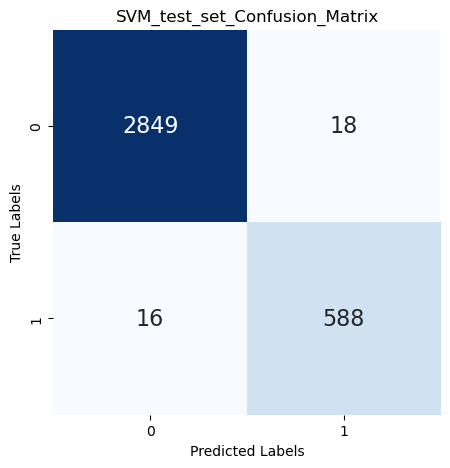

In [97]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(svm_tuned_cm2, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM_test_set_Confusion_Matrix')
plt.savefig("SVM_test_set_confusion_matrix.jpg", format="jpg")
plt.show()

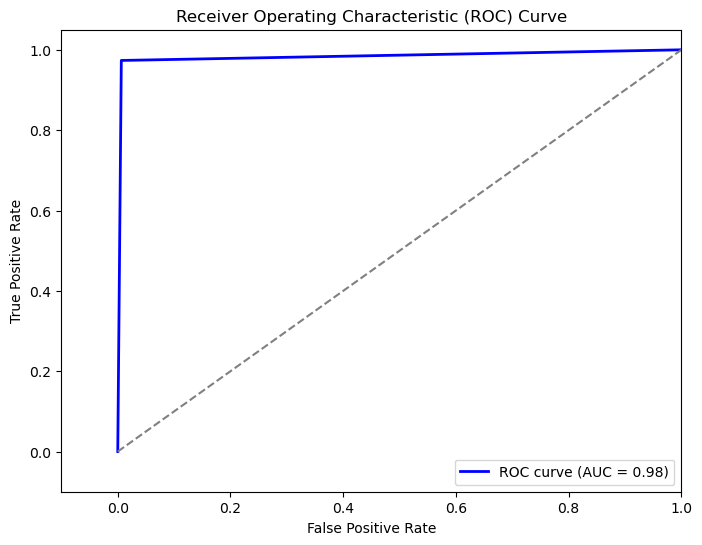

In [99]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("SVM_roc_curve_comparison_test_set.jpg", format="jpg")
plt.show()

# external dataset validation

In [101]:
# Evaluate the best model
svm_extern_pred = best_svm_2.predict(df3_filtered)
svm_extern_accuracy = accuracy_score(y1, svm_extern_pred)
from sklearn.metrics import classification_report
svm_extern_report = classification_report(y1, svm_extern_pred)

In [242]:
# Print evaluation results
print("Evaluation Results:")
print(f"Accuracy: {svm_extern_accuracy}")
print("Classification Report:")
print(svm_extern_report)

Evaluation Results:
Accuracy: 0.9842857142857143
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       680
           1       0.65      1.00      0.78        20

    accuracy                           0.98       700
   macro avg       0.82      0.99      0.89       700
weighted avg       0.99      0.98      0.99       700



In [103]:
#confusion matrix of external data set
svm_extern_cm = confusion_matrix(y1,svm_extern_pred)
print(svm_extern_cm)

[[669  11]
 [  0  20]]


In [105]:
fpr, tpr, _ = roc_curve(y1, svm_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

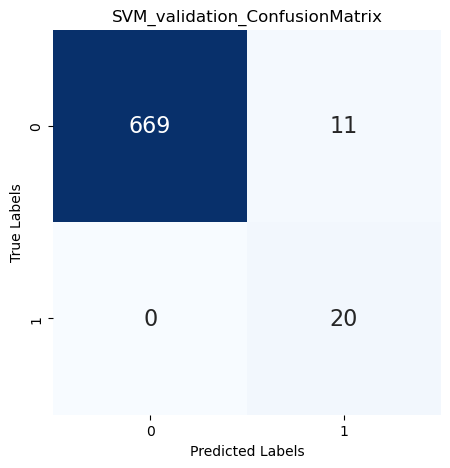

In [107]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(svm_extern_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM_validation_ConfusionMatrix')
plt.savefig("svm_external_set_confusion_matrix.jpg", format="jpg")
plt.show()

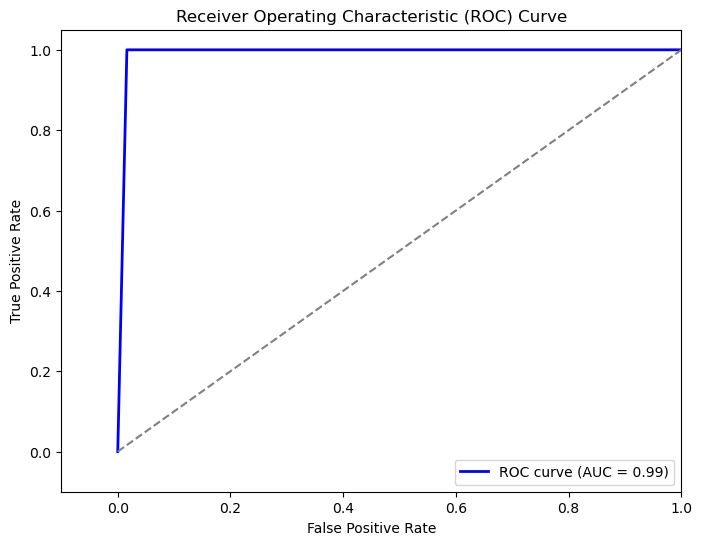

In [109]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("SVM_roc_curve_external_set.jpg", format="jpg")
plt.show()

# SVM Screening

In [111]:
SVM_screen_predictions = best_svm_2.predict(df2_filtered)

In [112]:
#calling maybridge smile file
maybridge_liberary = pd.read_csv('MAYBRIDGE_LIBERARY.csv')

In [113]:
maybridge_liberary

,smiles,name
0,c1cc(F)ccc1C(N2CC[NH2+]CC2)c3ccc(F)cc3,AC10018
1,n1c(N)nc(SC)c(c12)nc[nH]2,AC10402
2,C[NH+](C)Cc1c[nH]c(c12)ccc(c2)OCc3ccccc3,AC10608
3,O=C([O-])c1oc(Br)cc1,AC10702
4,O=C([O-])[C@@H]([NH3+])Cc1c[nH]c(c12)ccc(Br)c2,AC10751
...,...,...
55711,[O-][N+](=O)c1cc([N+]([O-])=O)ccc1O/N=C(C)/OCC,XBX00331
55712,c1cccc(c12)C(=O)N(C2=O)Oc(c3)ccc([N+]([O-])=O)...,XBX00332
55713,c1ccccc1-c(n2)c(nc(c23)ccc([N+]([O-])=O)c3)-c4...,XBX00337
55714,CCOC(=O)C1=C(C)NC(C)=C(C(=O)OCC)C1/C=C/c2ccccc2,XBX00342


In [117]:
maybridge_liberary['svm_pubchem_pred'] = SVM_screen_predictions

In [119]:
maybridge_liberary['svm_pubchem_pred'].value_counts()

svm_pubchem_pred
0    55678
1       38
Name: count, dtype: int64

In [112]:
maybridge_liberary

,smiles,name,svm_pubchem_pred
0,c1cc(F)ccc1C(N2CC[NH2+]CC2)c3ccc(F)cc3,AC10018,0
1,n1c(N)nc(SC)c(c12)nc[nH]2,AC10402,0
2,C[NH+](C)Cc1c[nH]c(c12)ccc(c2)OCc3ccccc3,AC10608,0
3,O=C([O-])c1oc(Br)cc1,AC10702,0
4,O=C([O-])[C@@H]([NH3+])Cc1c[nH]c(c12)ccc(Br)c2,AC10751,0
...,...,...,...
55711,[O-][N+](=O)c1cc([N+]([O-])=O)ccc1O/N=C(C)/OCC,XBX00331,0
55712,c1cccc(c12)C(=O)N(C2=O)Oc(c3)ccc([N+]([O-])=O)...,XBX00332,0
55713,c1ccccc1-c(n2)c(nc(c23)ccc([N+]([O-])=O)c3)-c4...,XBX00337,0
55714,CCOC(=O)C1=C(C)NC(C)=C(C(=O)OCC)C1/C=C/c2ccccc2,XBX00342,0


In [121]:
SVM_screen_predictions_gridsearch = best_svm.predict(df2_filtered)

In [123]:
maybridge_liberary['svm_pubchem_pred_gridsearch'] = SVM_screen_predictions_gridsearch

In [125]:
maybridge_liberary['svm_pubchem_pred'].value_counts()

svm_pubchem_pred
0    55678
1       38
Name: count, dtype: int64

In [114]:
maybridge_liberary.to_csv('SVM_Pubchem_MODEL_prediction.csv', index=False)

In [116]:
data = pd.read_csv('SVM_Pubchem_MODEL_prediction.csv')

In [118]:
data

,smiles,name,svm_pubchem_pred
0,c1cc(F)ccc1C(N2CC[NH2+]CC2)c3ccc(F)cc3,AC10018,0
1,n1c(N)nc(SC)c(c12)nc[nH]2,AC10402,0
2,C[NH+](C)Cc1c[nH]c(c12)ccc(c2)OCc3ccccc3,AC10608,0
3,O=C([O-])c1oc(Br)cc1,AC10702,0
4,O=C([O-])[C@@H]([NH3+])Cc1c[nH]c(c12)ccc(Br)c2,AC10751,0
...,...,...,...
55711,[O-][N+](=O)c1cc([N+]([O-])=O)ccc1O/N=C(C)/OCC,XBX00331,0
55712,c1cccc(c12)C(=O)N(C2=O)Oc(c3)ccc([N+]([O-])=O)...,XBX00332,0
55713,c1ccccc1-c(n2)c(nc(c23)ccc([N+]([O-])=O)c3)-c4...,XBX00337,0
55714,CCOC(=O)C1=C(C)NC(C)=C(C(=O)OCC)C1/C=C/c2ccccc2,XBX00342,0


# Hypertuning of Random Forest

In [94]:
rf_tuned = RandomForestClassifier(n_estimators = 200, min_samples_split = 2, min_samples_leaf = 1, max_features = 'sqrt', max_depth = 50,
                                 bootstrap = True)

In [96]:
rf_tuned.fit(x_train, y_train)

RandomForestClassifier(max_depth=50, n_estimators=200)

In [97]:
# Evaluate best model on test set
rf_pred = rf_tuned.predict(x_test)
rf_tuned_accuracy = accuracy_score(y_test, rf_pred)
rf_report = classification_report(y_test, rf_pred)
print("Test accuracy:", rf_tuned_accuracy)

Test accuracy: 0.9951022760011524


In [100]:
# Print evaluation results
print("Evaluation Results:")
print(f"Accuracy: {svm_tuned_accuracy2}")
print("Classification Report:")
print(svm_report2)

Evaluation Results:
Accuracy: 0.9902045520023048
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2867
           1       0.97      0.97      0.97       604

    accuracy                           0.99      3471
   macro avg       0.98      0.98      0.98      3471
weighted avg       0.99      0.99      0.99      3471



In [102]:
rf_tuned_cm = confusion_matrix(y_test,rf_pred)
print(rf_tuned_cm)

[[2857   10]
 [   7  597]]


In [104]:
#overfitting check
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_tuned, x_train, y_train, cv=cv, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std deviation:", cv_scores.std())

CV scores: [0.99074074 0.99258802 0.99320568 0.99135269 0.99629401]
Mean CV accuracy: 0.992836227209297
Std deviation: 0.0019363012894515628


In [112]:
fpr, tpr, _ = roc_curve(y_test, rf_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

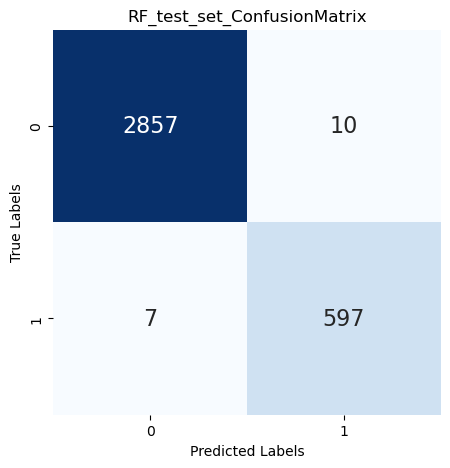

In [114]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(rf_tuned_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('RF_test_set_ConfusionMatrix')
plt.savefig("rf_test_set_confusion_matrix.jpg", format="jpg")
plt.show()

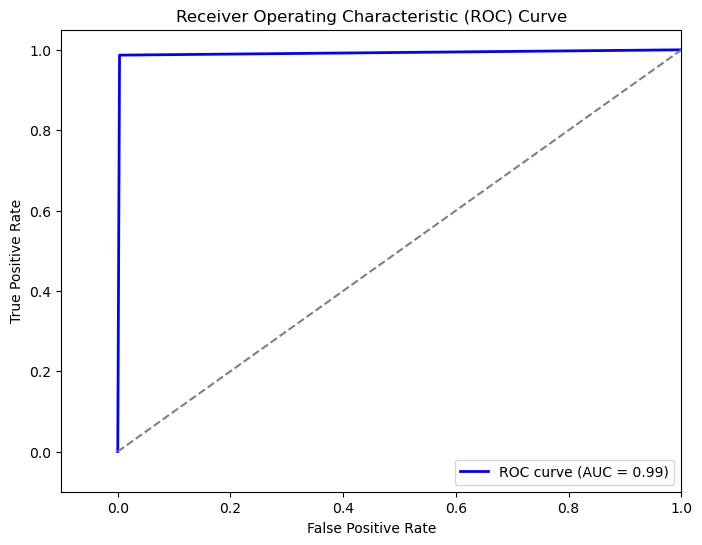

In [139]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("RF_roc_curve_test_set.jpg", format="jpg")
plt.show()

# RF external data validation

In [116]:
# Evaluate the best model
rf_extern_pred = rf_tuned.predict(df3_filtered)
rf_extern_accuracy = accuracy_score(y1, rf_extern_pred)
from sklearn.metrics import classification_report
rf_extern_report = classification_report(y1, rf_extern_pred)

In [118]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", rf_extern_accuracy)
print("Classification Report:")
print(rf_extern_report)


Evaluation Results:
Accuracy: 0.9842857142857143
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       680
           1       0.65      1.00      0.78        20

    accuracy                           0.98       700
   macro avg       0.82      0.99      0.89       700
weighted avg       0.99      0.98      0.99       700



In [120]:
#confusion matrix of external data set
rf_extern_cm = confusion_matrix(y1,rf_extern_pred)
print(rf_extern_cm)

[[669  11]
 [  0  20]]


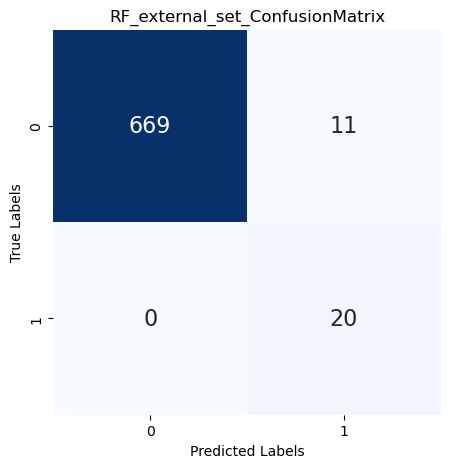

In [145]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(rf_extern_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('RF_external_set_ConfusionMatrix')
plt.savefig("rf_external_set_confusion_matrix.jpg", format="jpg")
plt.show()

In [122]:
fpr, tpr, _ = roc_curve(y1, rf_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

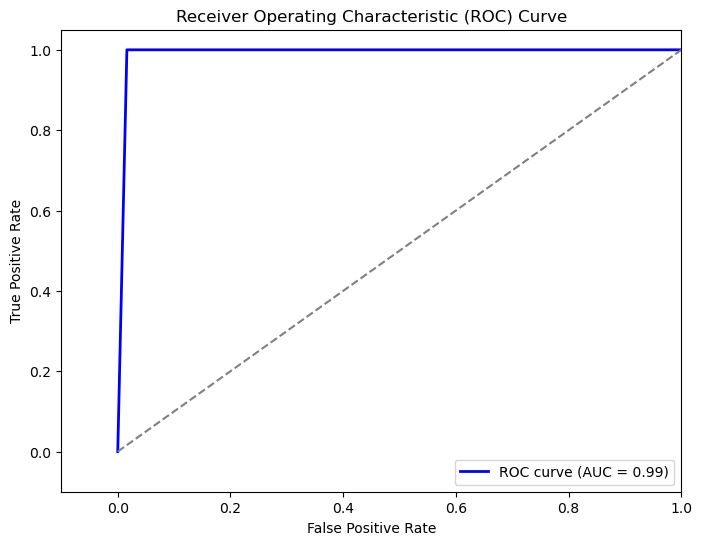

In [149]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("RF_roc_curve_EXTERNAL_set.jpg", format="jpg")
plt.show()

# screening of Random Forest model

In [194]:
rf_screen_predictions = rf_tuned.predict(df2_filtered)

In [196]:
maybridge_liberary['rf_pubchem_pred'] = rf_screen_predictions

In [198]:
maybridge_liberary['rf_pubchem_pred'].value_counts()

rf_pubchem_pred
0    55714
1        2
Name: count, dtype: int64

In [200]:
maybridge_liberary

,smiles,name,svm_pubchem_pred,rf_pubchem_pred
0,c1cc(F)ccc1C(N2CC[NH2+]CC2)c3ccc(F)cc3,AC10018,0,0
1,n1c(N)nc(SC)c(c12)nc[nH]2,AC10402,0,0
2,C[NH+](C)Cc1c[nH]c(c12)ccc(c2)OCc3ccccc3,AC10608,0,0
3,O=C([O-])c1oc(Br)cc1,AC10702,0,0
4,O=C([O-])[C@@H]([NH3+])Cc1c[nH]c(c12)ccc(Br)c2,AC10751,0,0
...,...,...,...,...
55711,[O-][N+](=O)c1cc([N+]([O-])=O)ccc1O/N=C(C)/OCC,XBX00331,0,0
55712,c1cccc(c12)C(=O)N(C2=O)Oc(c3)ccc([N+]([O-])=O)...,XBX00332,0,0
55713,c1ccccc1-c(n2)c(nc(c23)ccc([N+]([O-])=O)c3)-c4...,XBX00337,0,0
55714,CCOC(=O)C1=C(C)NC(C)=C(C(=O)OCC)C1/C=C/c2ccccc2,XBX00342,0,0


# XGBoost hypertuning

In [151]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01],
    'gamma': [0, 0.1, 0.2],
}

In [124]:
# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(x_train_normalized, y_train)

NameError: name 'GridSearchCV' is not defined

In [126]:
# Get best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

NameError: name 'grid_search' is not defined

In [128]:
# Get best model
#best_xgb = grid_search.best_estimator_
best_xgb = XGBClassifier(gamma= 0, learning_rate= 0.1, max_depth= 7, min_child_weight= 1, n_estimators= 200)

#fitting
best_xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [130]:
# Evaluate best model on test set
xgb_pred = best_xgb.predict(x_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_report = classification_report(y_test, xgb_pred)

In [132]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", xgb_accuracy)
print("Classification Report:")
print(xgb_report)


Evaluation Results:
Accuracy: 0.9945260731777585
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       0.99      0.98      0.98       604

    accuracy                           0.99      3471
   macro avg       0.99      0.99      0.99      3471
weighted avg       0.99      0.99      0.99      3471



In [134]:
xg_tuned_cm = confusion_matrix(y_test,xgb_pred)
print(xg_tuned_cm)

[[2859    8]
 [  11  593]]


In [136]:
#overfitting check
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_xgb, x_train, y_train, cv=cv, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std deviation:", cv_scores.std())

CV scores: [0.99135802 0.99320568 0.99505868 0.99382335 0.99629401]
Mean CV accuracy: 0.9939479483601369
Std deviation: 0.0016740315493357595


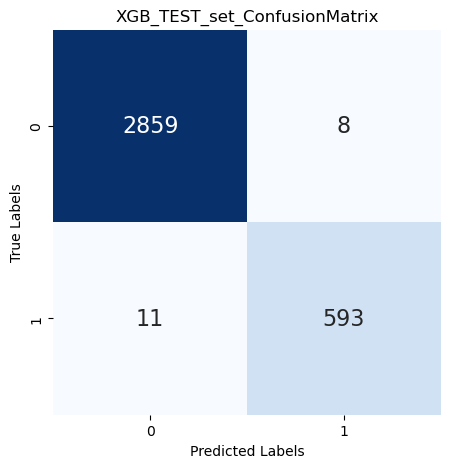

In [161]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(xg_tuned_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('XGB_TEST_set_ConfusionMatrix')
plt.savefig("XGB_TEST_set_confusion_matrix.jpg", format="jpg")
plt.show()

In [163]:
fpr, tpr, _ = roc_curve(y_test, xgb_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

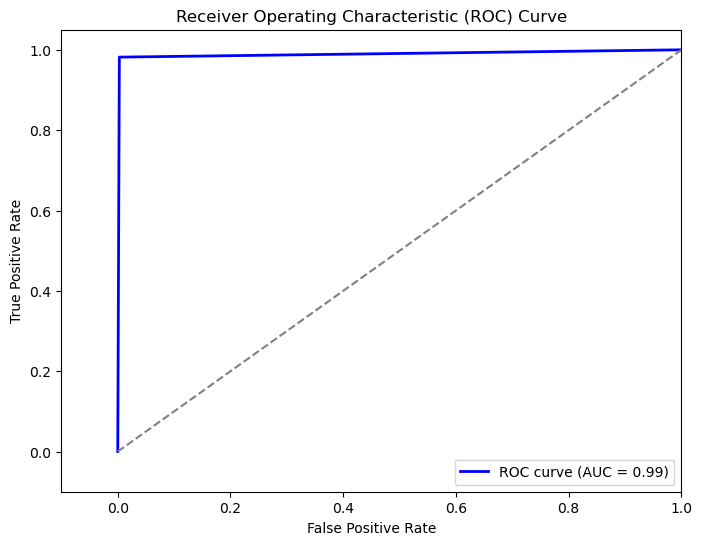

In [165]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("XGB_roc_curve_TEST_set.jpg", format="jpg")
plt.show()

# xgb externaldata validation

In [167]:
# Evaluate the best model
xgb_extern_pred = best_xgb.predict(df3_filtered)
xgb_extern_accuracy = accuracy_score(y1, xgb_extern_pred)
from sklearn.metrics import classification_report
xgb_extern_report = classification_report(y1, xgb_extern_pred)

In [228]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", xgb_extern_accuracy)
print("Classification Report:")
print(xgb_extern_report)


Evaluation Results:
Accuracy: 0.9842857142857143
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       680
           1       0.65      1.00      0.78        20

    accuracy                           0.98       700
   macro avg       0.82      0.99      0.89       700
weighted avg       0.99      0.98      0.99       700



In [169]:
#confusion matrix of external data set
xgb_extern_cm = confusion_matrix(y1,xgb_extern_pred)
print(xgb_extern_cm)

[[669  11]
 [  0  20]]


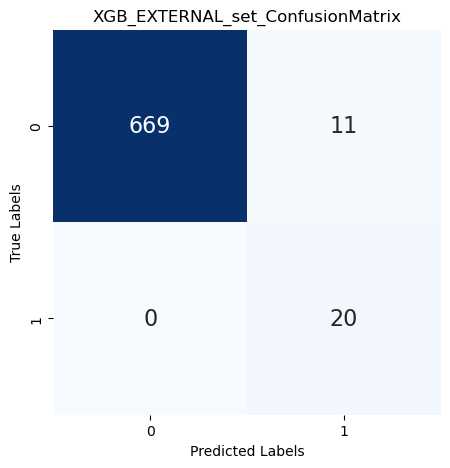

In [171]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(rf_extern_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('XGB_EXTERNAL_set_ConfusionMatrix')
plt.savefig("XGB_EXTERN_set_confusion_matrix.jpg", format="jpg")
plt.show()

In [173]:
fpr, tpr, _ = roc_curve(y1, xgb_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

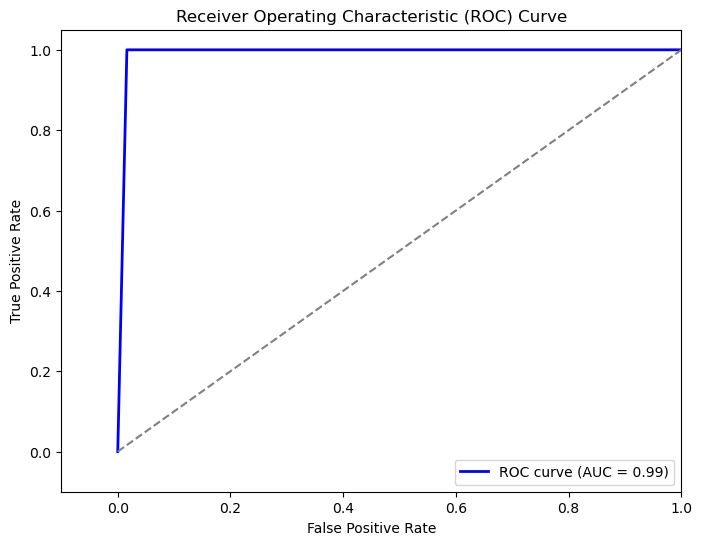

In [175]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("XGB_roc_curve_EXTERN_set.jpg", format="jpg")
plt.show()

# XGboost screening

In [228]:
xgb_screen_predictions = best_xgb.predict(df2_filtered)

In [230]:
maybridge_liberary['xgb_pubchem_pred'] = xgb_screen_predictions

In [232]:
maybridge_liberary['xgb_pubchem_pred'].value_counts()

xgb_pubchem_pred
0    55708
1        8
Name: count, dtype: int64

In [234]:
maybridge_liberary

,smiles,name,svm_pubchem_pred,rf_pubchem_pred,xgb_pubchem_pred
0,c1cc(F)ccc1C(N2CC[NH2+]CC2)c3ccc(F)cc3,AC10018,0,0,0
1,n1c(N)nc(SC)c(c12)nc[nH]2,AC10402,0,0,0
2,C[NH+](C)Cc1c[nH]c(c12)ccc(c2)OCc3ccccc3,AC10608,0,0,0
3,O=C([O-])c1oc(Br)cc1,AC10702,0,0,0
4,O=C([O-])[C@@H]([NH3+])Cc1c[nH]c(c12)ccc(Br)c2,AC10751,0,0,0
...,...,...,...,...,...
55711,[O-][N+](=O)c1cc([N+]([O-])=O)ccc1O/N=C(C)/OCC,XBX00331,0,0,0
55712,c1cccc(c12)C(=O)N(C2=O)Oc(c3)ccc([N+]([O-])=O)...,XBX00332,0,0,0
55713,c1ccccc1-c(n2)c(nc(c23)ccc([N+]([O-])=O)c3)-c4...,XBX00337,0,0,0
55714,CCOC(=O)C1=C(C)NC(C)=C(C(=O)OCC)C1/C=C/c2ccccc2,XBX00342,0,0,0


# KNN Hypertuning

In [177]:
# Define hyperparameters grid for tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # Number of neighbors
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Algorithm used to compute nearest neighbors
    'leaf_size': [10, 20, 30, 40],  # Leaf size passed to BallTree or KDTree
}

In [113]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [114]:
# Perform grid search
grid_search.fit(x_train_normalized, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'leaf_size': [10, 20, 30, 40],
                         'n_neighbors': [3, 5, 7, 9]},
             verbose=2)

In [115]:
# Print best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 3}


In [138]:
# Get the best model
#best_knn = grid_search.best_estimator_
knn = KNeighborsClassifier(algorithm = 'auto', leaf_size = 10, n_neighbors = 3)

In [140]:
knn.fit(x_train, y_train)

KNeighborsClassifier(leaf_size=10, n_neighbors=3)

In [142]:
# Evaluate the best model
knn_tuned_pred = knn.predict(x_test)
knn_tuned_accuracy = accuracy_score(y_test, knn_tuned_pred)
report = classification_report(y_test, knn_tuned_pred)

In [144]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", knn_tuned_accuracy)
print("Classification Report:")
print(report)


Evaluation Results:
Accuracy: 0.9890521463555172
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2867
           1       0.95      0.99      0.97       604

    accuracy                           0.99      3471
   macro avg       0.98      0.99      0.98      3471
weighted avg       0.99      0.99      0.99      3471



In [146]:
# Assuming y_test is the true labels for your test dataset
knn_tuned_cm = confusion_matrix(y_test, knn_tuned_pred)
print(knn_tuned_cm)

[[2838   29]
 [   9  595]]


In [148]:
#overfitting check
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn, x_train, y_train, cv=cv, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std deviation:", cv_scores.std())

CV scores: [0.9808642  0.98023471 0.9876467  0.9857937  0.98641137]
Mean CV accuracy: 0.9841901341324852
Std deviation: 0.003038431120715404


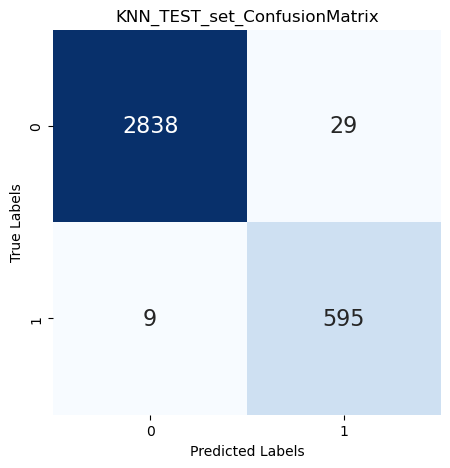

In [189]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(knn_tuned_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('KNN_TEST_set_ConfusionMatrix')
plt.savefig("KNN_TEST_set_confusion_matrix.jpg", format="jpg")
plt.show()

In [191]:
# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, knn_tuned_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

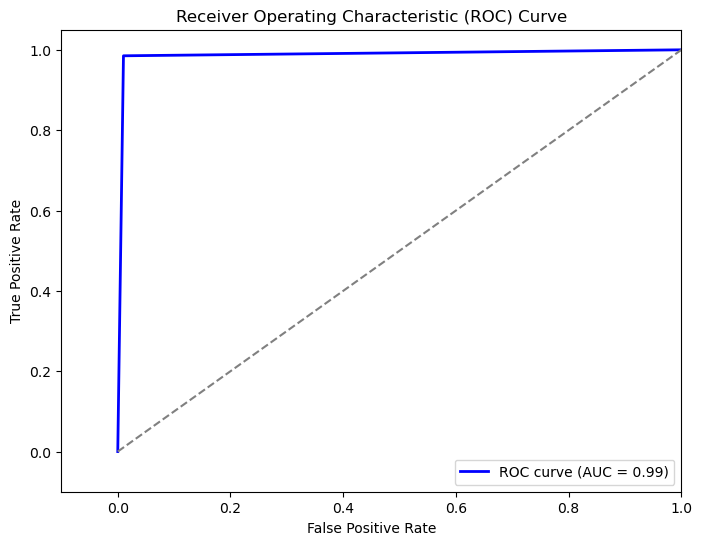

In [193]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("knn_roc_curve_test_set.jpg", format="jpg")
plt.show()

# knn external data validation

In [262]:
# Evaluate the best model
knn_extern_pred = knn.predict(df3_filtered)
knn_extern_accuracy = accuracy_score(y1, knn_extern_pred)
from sklearn.metrics import classification_report
knn_extern_report = classification_report(y1, knn_extern_pred)

In [264]:
# Print evaluation results
print("Evaluation Results:")
print("Accuracy:", knn_extern_accuracy)
print("Classification Report:")
print(knn_extern_report)


Evaluation Results:
Accuracy: 0.9757142857142858
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       680
           1       0.54      1.00      0.70        20

    accuracy                           0.98       700
   macro avg       0.77      0.99      0.84       700
weighted avg       0.99      0.98      0.98       700



In [197]:
#confusion matrix of external data set
knn_extern_cm = confusion_matrix(y1,knn_extern_pred)
print(knn_extern_cm)

[[663  17]
 [  0  20]]


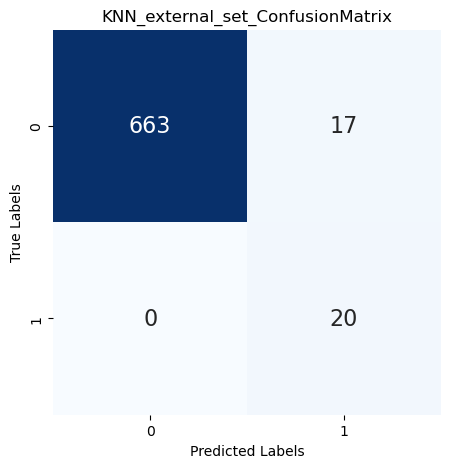

In [199]:
# Plot confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(knn_extern_cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('KNN_external_set_ConfusionMatrix')
plt.savefig("KNN_external_set_confusion_matrix.jpg", format="jpg")
plt.show()

In [205]:
# Calculate ROC curve
fpr, tpr, _ = roc_curve(y1,knn_extern_pred)
# Calculate AUC
roc_auc = auc(fpr, tpr)

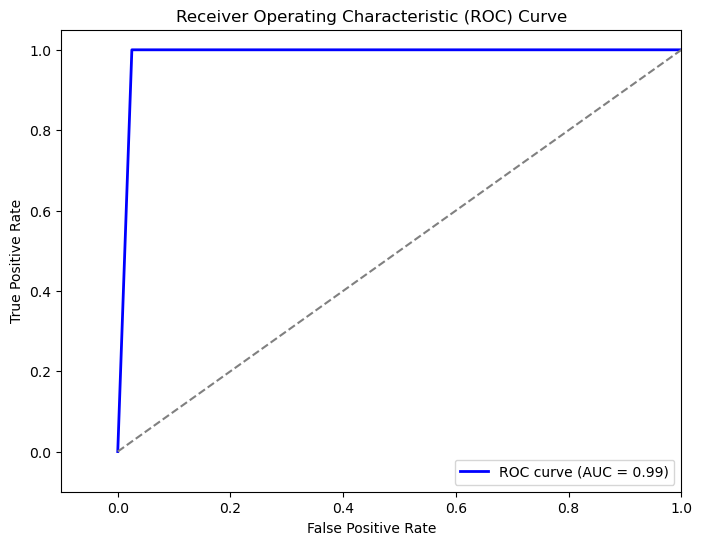

In [207]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("knn_roc_curve_external_set.jpg", format="jpg")
plt.show()

# roc_auc combine plot for test set

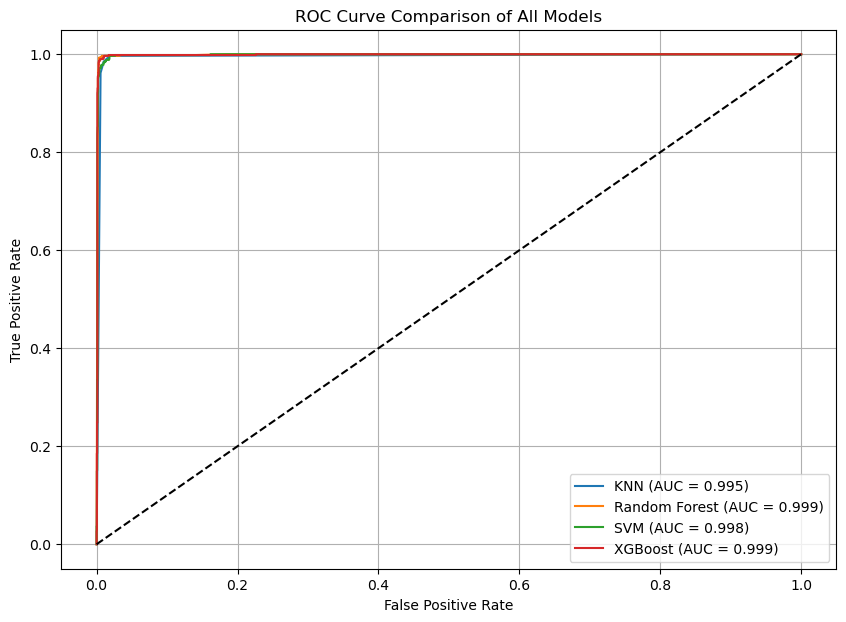

In [222]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------
# KNN (use probability scores)
# -----------------------------
knn_tuned_pred = knn.predict(x_test)
knn_pred_proba = knn.predict_proba(x_test)[:, 1]

fpr_knn_test, tpr_knn_test, _ = roc_curve(y_test, knn_pred_proba)
auc_knn = auc(fpr_knn_test, tpr_knn_test)

# -----------------------------
# Random Forest
# -----------------------------
rf_pred = rf_tuned.predict(x_test)
rf_pred_proba = rf_tuned.predict_proba(x_test)[:, 1]

fpr_rf_test, tpr_rf_test, _ = roc_curve(y_test, rf_pred_proba)
auc_rf = auc(fpr_rf_test, tpr_rf_test)

# -----------------------------
# SVM (requires decision function, not predict_proba)
# -----------------------------
svm_tuned_pred = best_svm_2.predict(x_test)
svm_scores = best_svm_2.decision_function(x_test)

fpr_svm_test, tpr_svm_test, _ = roc_curve(y_test, svm_scores)
auc_svm = auc(fpr_svm_test, tpr_svm_test)

# -----------------------------
# XGBoost (use predict_proba)
# -----------------------------
xgb_pred = best_xgb.predict(x_test)
xgb_pred_proba = best_xgb.predict_proba(x_test)[:, 1]

fpr_xgb_test, tpr_xgb_test, _ = roc_curve(y_test, xgb_pred_proba)
auc_xgb = auc(fpr_xgb_test, tpr_xgb_test)

# -----------------------------
# PLOT ALL ROC CURVES TOGETHER
# -----------------------------
plt.figure(figsize=(10, 7))

plt.plot(fpr_knn_test, tpr_knn_test, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot(fpr_rf_test, tpr_rf_test, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_svm_test, tpr_svm_test, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_xgb_test, tpr_xgb_test, label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.plot([0, 1], [0, 1], 'k--')

plt.title('ROC Curve Comparison of All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
# Save the figure at 900 dpi
plt.savefig('combine_test_roc_curves.png', dpi=900, bbox_inches='tight')
plt.show()


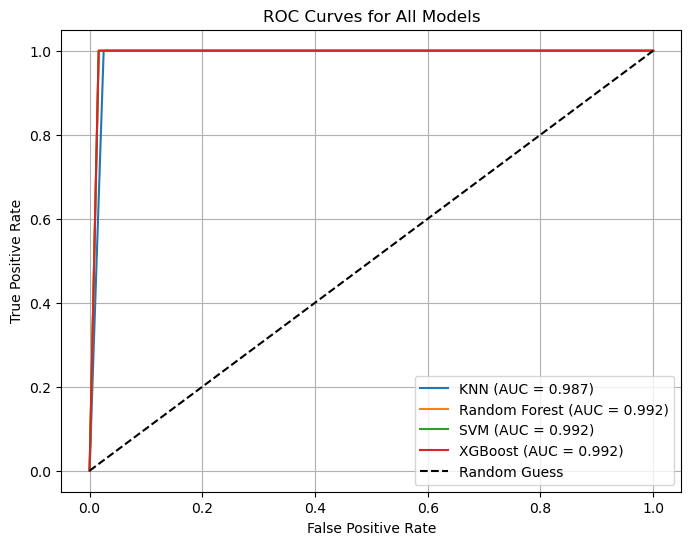

In [224]:
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------
# KNN
# -----------------------
knn_pred = knn.predict(df3_filtered)
knn_acc = accuracy_score(y1, knn_pred)
knn_report = classification_report(y1, knn_pred)
fpr_knn, tpr_knn, _ = roc_curve(y1, knn_pred)
auc_knn = auc(fpr_knn, tpr_knn)

# -----------------------
# Random Forest
# -----------------------
rf_pred = rf_tuned.predict(df3_filtered)
rf_acc = accuracy_score(y1, rf_pred)
rf_report = classification_report(y1, rf_pred)
fpr_rf, tpr_rf, _ = roc_curve(y1, rf_pred)
auc_rf = auc(fpr_rf, tpr_rf)

# -----------------------
# SVM
# -----------------------
svm_pred = best_svm_2.predict(df3_filtered)
svm_acc = accuracy_score(y1, svm_pred)
svm_report = classification_report(y1, svm_pred)
fpr_svm, tpr_svm, _ = roc_curve(y1, svm_pred)
auc_svm = auc(fpr_svm, tpr_svm)

# -----------------------
# XGBoost
# -----------------------
xgb_pred = best_xgb.predict(df3_filtered)
xgb_acc = accuracy_score(y1, xgb_pred)
xgb_report = classification_report(y1, xgb_pred)
fpr_xgb, tpr_xgb, _ = roc_curve(y1, xgb_pred)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# ------------------------------------------------------------
# 📈 Plot All ROC Curves Together
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid(True)
# Save the figure at 900 dpi
plt.savefig('combine_external_roc_curves.png',dpi=900, bbox_inches='tight')
plt.show()

# KNN Screening

In [272]:
knn_screen_predictions = knn.predict(df2_filtered)

In [273]:
maybridge_liberary['knn_pubchem_pred'] = knn_screen_predictions

In [274]:
maybridge_liberary['knn_pubchem_pred'].value_counts()

knn_pubchem_pred
0    54073
1     1643
Name: count, dtype: int64

In [275]:
maybridge_liberary

,smiles,name,svm_pubchem_pred,rf_pubchem_pred,xgb_pubchem_pred,knn_pubchem_pred
0,c1cc(F)ccc1C(N2CC[NH2+]CC2)c3ccc(F)cc3,AC10018,0,0,0,0
1,n1c(N)nc(SC)c(c12)nc[nH]2,AC10402,0,0,0,0
2,C[NH+](C)Cc1c[nH]c(c12)ccc(c2)OCc3ccccc3,AC10608,0,0,0,0
3,O=C([O-])c1oc(Br)cc1,AC10702,0,0,0,0
4,O=C([O-])[C@@H]([NH3+])Cc1c[nH]c(c12)ccc(Br)c2,AC10751,0,0,0,0
...,...,...,...,...,...,...
55711,[O-][N+](=O)c1cc([N+]([O-])=O)ccc1O/N=C(C)/OCC,XBX00331,0,0,0,0
55712,c1cccc(c12)C(=O)N(C2=O)Oc(c3)ccc([N+]([O-])=O)...,XBX00332,0,0,0,0
55713,c1ccccc1-c(n2)c(nc(c23)ccc([N+]([O-])=O)c3)-c4...,XBX00337,0,0,0,0
55714,CCOC(=O)C1=C(C)NC(C)=C(C(=O)OCC)C1/C=C/c2ccccc2,XBX00342,0,0,0,0


In [276]:
maybridge_liberary['knn_pubchem_pred'].value_counts()

knn_pubchem_pred
0    54073
1     1643
Name: count, dtype: int64

# saving the model result

In [282]:
maybridge_liberary.to_csv('Pubchem_MODEL_prediction.csv', index=False)

In [284]:
data = pd.read_csv('Pubchem_MODEL_prediction.csv')

In [286]:
data

,smiles,name,svm_pubchem_pred,rf_pubchem_pred,xgb_pubchem_pred,knn_pubchem_pred
0,c1cc(F)ccc1C(N2CC[NH2+]CC2)c3ccc(F)cc3,AC10018,0,0,0,0
1,n1c(N)nc(SC)c(c12)nc[nH]2,AC10402,0,0,0,0
2,C[NH+](C)Cc1c[nH]c(c12)ccc(c2)OCc3ccccc3,AC10608,0,0,0,0
3,O=C([O-])c1oc(Br)cc1,AC10702,0,0,0,0
4,O=C([O-])[C@@H]([NH3+])Cc1c[nH]c(c12)ccc(Br)c2,AC10751,0,0,0,0
...,...,...,...,...,...,...
55711,[O-][N+](=O)c1cc([N+]([O-])=O)ccc1O/N=C(C)/OCC,XBX00331,0,0,0,0
55712,c1cccc(c12)C(=O)N(C2=O)Oc(c3)ccc([N+]([O-])=O)...,XBX00332,0,0,0,0
55713,c1ccccc1-c(n2)c(nc(c23)ccc([N+]([O-])=O)c3)-c4...,XBX00337,0,0,0,0
55714,CCOC(=O)C1=C(C)NC(C)=C(C(=O)OCC)C1/C=C/c2ccccc2,XBX00342,0,0,0,0


# EXTRACTING ACTIVE MOLECULES OF SVM FROM THE FILE

In [99]:
#extracting the SVM actives from the smiles file of screened liberary
active_rows = data[data['svm_pubchem_pred'] == 1]

In [100]:
#creating the separate csv file of actives
active_rows.to_csv('SVM_PUBCHEM_actives2.csv', index=False)

# Extracting active molecules of RF 

In [101]:
#extracting the rf actives from the smiles file of screened liberary
active_rows = data[data['rf_pubchem_pred'] == 1]

In [102]:
#creating the separate csv file of actives
active_rows.to_csv('RF_PUBCHEM_actives.csv', index=False)

# Extracting actives of XGBoost

In [103]:
#extracting the rf actives from the smiles file of screened liberary
active_rows = data[data['xgb_pubchem_pred'] == 1]
#creating the separate csv file of actives
active_rows.to_csv('XGB_PUBCHEM_actives.csv', index=False)

# Extracting actives of knn

In [288]:
#extracting the rf actives from the smiles file of screened liberary
active_rows = data[data['knn_pubchem_pred'] == 1]
#creating the separate csv file of actives
active_rows.to_csv('KNN_PUBCHEM_actives.csv', index=False)

In [292]:
active_rows

,smiles,name,svm_pubchem_pred,rf_pubchem_pred,xgb_pubchem_pred,knn_pubchem_pred
8,[nH]1c(=O)cc(C)c(c12)cccc2,AC12157,0,0,0,1
19,c1cncn1-c2ccc(O)cc2,AC17979,0,0,0,1
25,n1c(C)cc(C)c(c12)c(=O)[nH]cn2,AC27191,0,0,0,1
33,Nc1nc(N)nc(c12)ncc(n2)CO,AC29806,0,0,0,1
46,c1cccc(c2C(=O)[O-])c1nc(c23)cccc3,AC40022,0,0,0,1
...,...,...,...,...,...,...
55171,Cc1c(Cl)ccc(c1)OC(=O)c2n(nc(c2)C(C)(C)C)Cc3c(C...,SPB08331,0,0,0,1
55212,Clc1cccc(Cl)c1-c2c(c(on2)C)C(=O)Nc(cc3)cnc3OC,SPB08387,0,0,0,1
55609,c1cc(Br)sc1-c(n2)c(=O)[nH]c(c23)cccc3,XBX00043,0,0,0,1
55679,O=c1cc(C(=O)OC)[nH]c(c12)ccc(c2C(=O)C)OCc3ccccc3,XBX00250,0,0,0,1


# Saving the trained models and screening

In [105]:
import joblib

In [106]:
joblib.dump(best_svm_2, 'SVM_model.pkl')

['SVM_model.pkl']

In [107]:
svm_trained = joblib.load('svm_model.pkl')

In [109]:
a = svm_trained.predict(df2_filtered)

In [111]:
maybridge_liberary['svm_model_pkl'] = a

In [112]:
maybridge_liberary['svm_model_pkl'].value_counts()

0    55678
1       38
Name: svm_model_pkl, dtype: int64

# Save the rest of the model

In [113]:
joblib.dump(rf_tuned, 'RF_model.pkl')

['RF_model.pkl']

In [114]:
joblib.dump(best_xgb, 'xgb_model.pkl')

['xgb_model.pkl']

In [115]:
joblib.dump(knn, 'knn_model.pkl')

['knn_model.pkl']